In [1]:
import os
import glob
from collections import defaultdict
import re
import rasterio
from rasterio.transform import Affine
from rasterio.windows import Window
from rasterio.transform import rowcol
from rasterio.warp import reproject, Resampling, calculate_default_transform
import rioxarray
import xarray as xr
import numpy as np
import pdb
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from skimage.filters import threshold_otsu
import rioxarray
import geopandas as gpd
import pandas as pd

In [2]:
regions = ['Beaufort', 'Chukchi']
basepath = Path("D:/MyDrive/Stability/RawData/Monthly_Averages/Masked")

files_by_region = {}

for regs in regions:
    datadir_reg = basepath / regs 
    file_list = [f for f in datadir_reg.iterdir() if f.name.endswith(".tif")]
    files_by_region[regs] = sorted(file_list)  # sort for consistency

pairs_by_month = []
for f in files_by_region[regions[0]]:
    month = f.name[0:3]  # Python is 0-based indexing, so [13:15] gives chars 14–15
    match = next((g for g in files_by_region[regions[1]] if g.name[0:3] == month), None)
    if match:
        pairs_by_month.append((f, match))
pairs_by_month_dict = {}
for f_beaufort, f_chukchi in pairs_by_month:
    month = f_beaufort.name[0:3]  # extract month (chars 14–15)
    pairs_by_month_dict[month] = (f_beaufort, f_chukchi)

In [3]:
pairs_by_month_dict

{'APR': (WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Beaufort/APR.tif'),
  WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Chukchi/APR.tif')),
 'DEC': (WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Beaufort/DEC.tif'),
  WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Chukchi/DEC.tif')),
 'FEB': (WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Beaufort/FEB.tif'),
  WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Chukchi/FEB.tif')),
 'JAN': (WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Beaufort/JAN.tif'),
  WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Chukchi/JAN.tif')),
 'MAR': (WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Beaufort/MAR.tif'),
  WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Chukchi/MAR.tif')),
 'MAY': (WindowsPath('D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Beaufort/M

In [4]:
def raster_distribution(raster_path):
    """Load a raster and return its valid values as a 1D array (nodata excluded)."""
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(float)
        nodata_val = src.nodata  # read nodata from metadata if available

    # Always exclude the known hardcoded nodata values
    nodata_values = {-9999, -3.402823e+38}
    if nodata_val is not None:
        nodata_values.add(nodata_val)

    # Mask out nodata and invalid values
    mask = np.isfinite(arr) & ~np.isin(arr, list(nodata_values))
    arr = arr[mask]

    return arr


def calculate_distributions_percentage(pairs_by_month_dict, bins=100):
    """
    For each month:
      - calculate distribution for Beaufort and Chukchi separately
      - calculate distribution for combined (both regions)
    Returns a dict of pandas.DataFrame with percentages per bin.
    """
    results = {}
    
    for month, (f_beaufort, f_chukchi) in pairs_by_month_dict.items():
        # Extract valid values (nodata excluded)
        vals_beaufort = raster_distribution(f_beaufort)
        vals_chukchi = raster_distribution(f_chukchi)
        vals_combined = np.concatenate([vals_beaufort, vals_chukchi])
        
        # Determine min/max for bins
        min_val = 1e-9  # start first bin at 0.000000001
        max_val = max(vals_combined.max(), 1e-9)  # ensure max_val > min_val
        
        # Create bins manually
        bins_edges = np.linspace(min_val, max_val, bins + 1)
        
        # Histograms
        hist_beaufort, _ = np.histogram(vals_beaufort, bins=bins_edges)
        hist_chukchi, _ = np.histogram(vals_chukchi, bins=bins_edges)
        hist_combined, _ = np.histogram(vals_combined, bins=bins_edges)
        
        # Convert to percentages
        hist_beaufort = hist_beaufort / hist_beaufort.sum() * 100
        hist_chukchi = hist_chukchi / hist_chukchi.sum() * 100
        hist_combined = hist_combined / hist_combined.sum() * 100
        
        # Store as DataFrame
        df = pd.DataFrame({
            "bin_left": bins_edges[:-1],
            "bin_right": bins_edges[1:],
            "Beaufort": hist_beaufort,
            "Chukchi": hist_chukchi,
            "Combined": hist_combined
        })
        
        results[month] = df
    
    return results

In [5]:
results = calculate_distributions_percentage(pairs_by_month_dict, bins=50)

# Access April distributions
print(results["APR"])

        bin_left  bin_right  Beaufort   Chukchi  Combined
0   1.000000e-09   0.000002  0.041297  0.230528  0.129277
1   1.522524e-06   0.000003  0.779606  1.231520  0.989717
2   3.044049e-06   0.000005  1.038589  2.212299  1.584288
3   4.565573e-06   0.000006  1.009824  2.794627  1.839642
4   6.087098e-06   0.000008  1.356811  3.504346  2.355276
5   7.608622e-06   0.000009  2.105849  4.395974  3.170609
6   9.130147e-06   0.000011  3.289309  5.391394  4.266642
7   1.065167e-05   0.000012  4.676499  6.209603  5.389293
8   1.217320e-05   0.000014  6.049640  6.990884  6.487257
9   1.369472e-05   0.000015  7.296137  7.587852  7.431765
10  1.521624e-05   0.000017  8.278239  7.872460  8.089578
11  1.673777e-05   0.000018  8.930538  7.727698  8.371295
12  1.825929e-05   0.000020  8.896077  7.334927  8.170243
13  1.978082e-05   0.000021  8.213589  6.597130  7.462040
14  2.130234e-05   0.000023  7.295092  5.747892  6.575745
15  2.282387e-05   0.000024  6.279857  4.947601  5.660444
16  2.434539e-

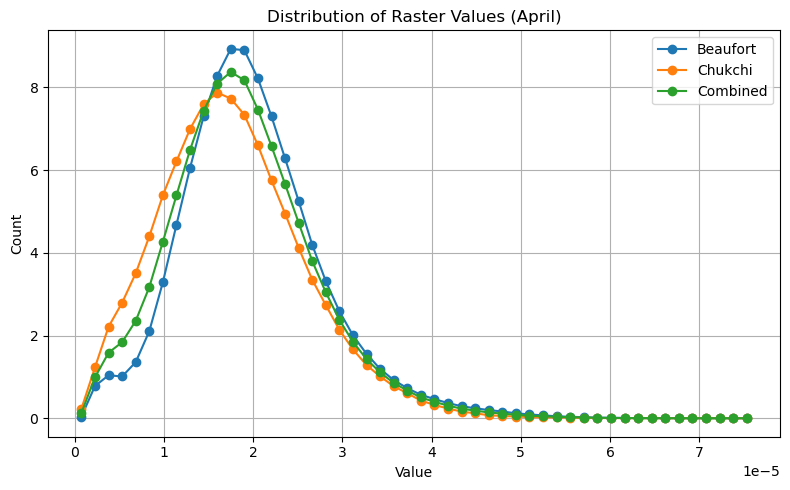

In [6]:
df_apr = results["APR"]

# Compute bin centers for plotting
bin_centers = (df_apr["bin_left"] + df_apr["bin_right"]) / 2

plt.figure(figsize=(8, 5))

plt.plot(bin_centers, df_apr["Beaufort"], label="Beaufort", marker="o")
plt.plot(bin_centers, df_apr["Chukchi"], label="Chukchi", marker="o")
plt.plot(bin_centers, df_apr["Combined"], label="Combined", marker="o")

plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Distribution of Raster Values (April)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
results['JAN']

,bin_left,bin_right,Beaufort,Chukchi,Combined
0,1.000000e-09,0.000001,0.044854,0.362250,0.097656
1,1.489282e-06,0.000003,0.821442,2.920712,1.170679
2,2.977564e-06,0.000004,1.312685,5.237674,1.965651
3,4.465846e-06,0.000006,1.264252,5.493520,1.967839
4,5.954128e-06,0.000007,1.301949,4.957917,1.910160
5,7.442410e-06,0.000009,1.508800,4.137774,1.946160
6,8.930692e-06,0.000010,1.939204,3.742050,2.239128
7,1.041897e-05,0.000012,2.514428,3.536416,2.684448
8,1.190726e-05,0.000013,3.182938,3.298503,3.202164
9,1.339554e-05,0.000015,4.118185,3.554349,4.024384


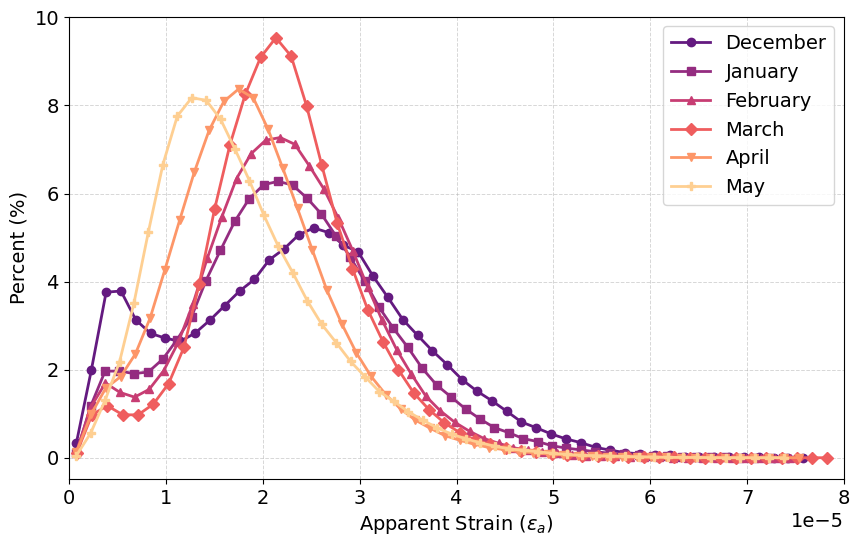

In [11]:
months_full = ['December','January','February','March','April','May']
months = ['DEC','JAN','FEB','MAR','APR','MAY']
cmap = plt.get_cmap("magma")
colors = [cmap(i) for i in np.linspace(0.3, 0.9, len(months))]
markers = ['o', 's', '^', 'D', 'v', 'P']
fig, ax = plt.subplots(figsize=(10,6))
for (m, m_full, color, marker) in zip(months, months_full, colors, markers):
    df = results[m]

    # Compute bin centers for plotting
    bin_centers = (df["bin_left"] + df["bin_right"]) / 2
    ax.plot(bin_centers, df["Combined"],
             label=f"{m_full}", 
             color=color, 
             marker=marker, 
             linewidth=2, 
             markersize=6)
ax.tick_params(axis='both', labelsize=14)
ax.xaxis.get_offset_text().set_fontsize(14)
ax.set_xlim([0, 0.00008])
ax.set_xlabel(r"Apparent Strain ($\epsilon_a$)",fontsize=14)
ax.set_ylabel("Percent (%)",fontsize=14)
plt.legend(loc='upper right',fontsize=14)
plt.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.5)
plt.show()
fig.savefig("D:/MyDrive/Stability/Figs/total_distribution_05_02_26.png", dpi=300, bbox_inches="tight") 

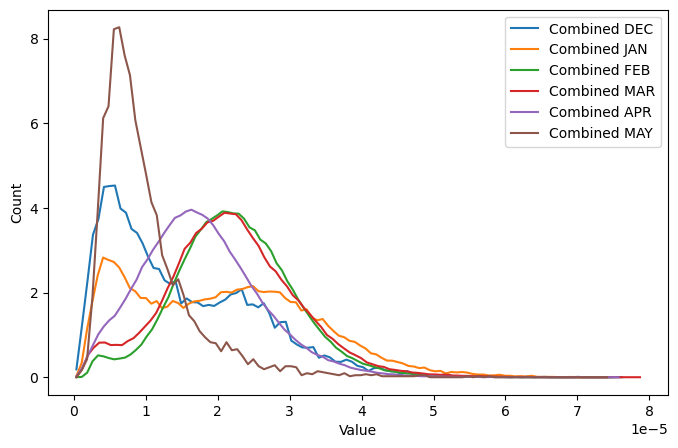

In [9]:
plt.figure(figsize=(8, 5))
for m in months:
    df = results[m]

    # Compute bin centers for plotting
    bin_centers = (df["bin_left"] + df["bin_right"]) / 2
    plt.plot(bin_centers, df["Chukchi"], label=f"Combined {m}")

plt.xlabel("Value")
plt.ylabel("Count")
plt.legend(loc='upper right')

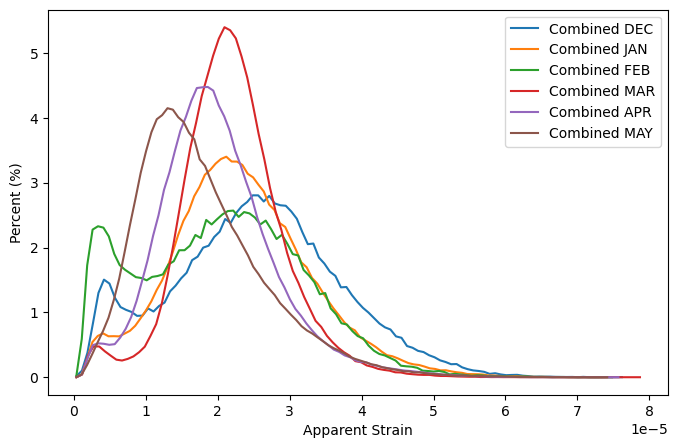

In [10]:
plt.figure(figsize=(8, 5))
for m in months:
    df = results[m]

    # Compute bin centers for plotting
    bin_centers = (df["bin_left"] + df["bin_right"]) / 2
    plt.plot(bin_centers, df["Beaufort"], label=f"Combined {m}")

plt.xlabel("Apparent Strain")
plt.ylabel("Percent (%)")
plt.legend(loc='upper right')